# 📐 Showcase: Classe `Shape` (Manipolazione Geometrica 2D)

Questo notebook funge da tutorial interattivo per l'utilizzo della classe base `Shape`. La classe è progettata per semplificare l'istanziazione e la manipolazione di poligoni irregolari, offrendo un'interfaccia ad alto livello (basata su Shapely) per l'analisi geometrica e le trasformazioni spaziali.

> **Obiettivi del tutorial:**
> 1. Inizializzare una forma da un set di coordinate.
>     + Estrarre e analizzare le proprietà geometriche (Area, Perimetro, Baricentro, Bounding Box).
>     + Rappresentazione grafica dello stato iniziale
> 2. Applicare trasformazioni affini:
>     + Traslazione
>     + Rotazione
>     + Ridimensionamento
> 3. Analizzare la differenza critica tra **Ridimensionamento Baricentrica** e **Buffer (Offset)** nella gestione dei contorni irregolari.
> 4. Eseguire la **Discretizzazione** del perimetro per operazioni di campionamento.

In [37]:
%matplotlib inline
import numpy as np
from matplotlib import pyplot as plt
from src.models.shape.generic_shape import Shape

from shapely.geometry import LineString

from src.utils import _tolerated_mcd

## 1. Inizializzazione della Forma

L'istanziazione della classe `Shape` richiede due argomenti principali da passare al costruttore, rigorosamente in quest'ordine:

* **`control_points` (ArrayLike):** L'insieme dei punti di controllo (i vertici) che delimitano il perimetro della figura geometrica. Essendo un tipo `ArrayLike`, sono validi diversi formati: liste di tuple `[(x, y), ...]`, liste di liste, oppure array NumPy 2D.
* **`reference_point` (ArrayLike):** Le coordinate 2D del punto di ancoraggio. Questo punto funge da sistema di riferimento locale per le trasformazioni spaziali (solitamente impostato sull'origine `(0, 0)`). Anche in questo caso puoi usare tuple, liste o array.

> **⚠️ Parametri Avanzati (Uso Interno):**
> Il costruttore prevede due ulteriori argomenti opzionali booleani (`__skip` e `__order`). Il loro utilizzo è caldamente sconsigliato a meno che non si abbia l'assoluta certezza della validità e dell'integrità dei dati in ingresso:
> * `__skip`: Permette di saltare i controlli di sicurezza geometrica (utile per ottimizzare le prestazioni se i dati sono già stati validati a monte).
> * `__order`: Predisposto per forzare l'ordinamento automatico dei punti (funzionalità non ancora implementata).

In [38]:
# Definizione dei parametri geometrici
# Definiamo l'origine locale per le trasformazioni (solitamente 0,0)
riferimento_per_le_trasformazioni = (0.0, 0.0)

# Coordinate (x, y) dei vertici in senso antiorario (CCW)
punti_di_controllo = [
    (-200., 200.),
    (300., 300.),
    (400., -200.),
    (0., -500.),
    (-300., 100.)
]

# Generazione della forma
# La classe Shape incapsula i punti e genera l'oggetto geometrico
forma_generica = Shape(
    punti_di_controllo,
    riferimento_per_le_trasformazioni
)

## 1.1. Estrazione e Analisi delle Proprietà Geometriche

Una caratteristica avanzata della classe `Shape` è l'implementazione del **lazy caching** (valutazione pigra). Le proprietà geometriche complesse della figura (come area, perimetro, bounding box, ecc.) non vengono calcolate nel momento in cui l'oggetto viene creato.

Vengono invece calcolate **solo alla prima richiesta esplicita**. Questo approccio architetturale offre due vantaggi cruciali:
* **Costruttore ultraleggero:** L'istanziazione iniziale della forma è pressoché istantanea, indipendentemente dal numero di vertici del poligono.
* **Efficienza computazionale:** Si evita di sovraccaricare la CPU con calcoli matematici (gestiti tramite Shapely) per proprietà che potrebbero non essere mai utilizzate nello script. Una volta calcolata la prima volta, la proprietà viene salvata in cache, rendendo gli accessi successivi immediati.

In [39]:
# Analisi delle Proprietà
print("--- PROPRIETÀ GEOMETRICHE ---")
print(f"Vertici originari:\n{forma_generica.control_points}")

# È in questo esatto momento che scatta il calcolo lazy del baricentro.
# Nelle chiamate successive, il valore verrà recuperato istantaneamente dalla cache.
print(f"Baricentro: {forma_generica.barycenter}")
print(f"Origine (Rif. standard): {forma_generica.origin}\n")

print("--- VERIFICA PRECISIONE MATEMATICA ---")
# Anche Area, Lunghezza e Bounds vengono calcolati on-demand tramite Shapely
print(f"Area Shapely: {forma_generica.area:.4f}")
print(f"Perimetro Shapely: {forma_generica.length:.4f}")
print(f"Bounds (BBox): {forma_generica.bounds}")
print(f"Verso di percorrenza dei vertici (CCW): {forma_generica.ccw}")

--- PROPRIETÀ GEOMETRICHE ---
Vertici originari:
[-200.  200.  300.  300.  400. -200.    0. -500. -300.  100. -200.]
Baricentro: [ 73.91304348 -53.14009662]
Origine (Rif. standard): [0. 0.]

--- VERIFICA PRECISIONE MATEMATICA ---
Area Shapely: 345000.0000
Perimetro Shapely: 2332.0457
Bounds (BBox): (-300.0, -500.0, 400.0, 300.0)
Verso di percorrenza dei vertici (CCW): False


### 1.2. Rappresentazione Grafica dello Stato Iniziale

Dopo aver istanziato la forma e analizzato le sue proprietà numeriche, la validazione visiva è uno step fondamentale. Ci permette di confermare che la sequenza dei vertici sia corretta e di visualizzare le relazioni spaziali interne.

In questo plot evidenziamo tre elementi chiave:
* Il **Perimetro** (linea bianca): costruito estraendo le coordinate dall'oggetto Shapely sottostante.
* L'**Origine** (punto verde): il nostro punto di ancoraggio (`reference_point`), solitamente `(0, 0)`.
* Il **Baricentro** (punto rosso): il centro di massa calcolato automaticamente, che fungerà da perno naturale per le operazioni successive (come rotazione e scalatura).

> 💡 **Nota Tecnica (Matplotlib):** Quando si visualizzano geometrie 2D, è cruciale impostare `ax.set_aspect('equal')`. Questo garantisce che la scala dell'asse X sia identica a quella dell'asse Y, evitando che la forma subisca distorsioni visive (es. un quadrato che sembra un rettangolo).

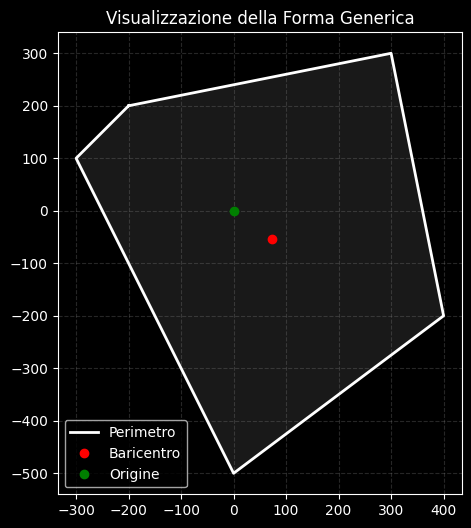

In [40]:
# Inizializzazione della figura: l'aspetto 'equal' è fondamentale in geometria
fig1, ax1 = plt.subplots(figsize=(6, 6))
ax1.set_aspect('equal') # Evita distorsioni visive (1 unità X = 1 unità Y)
ax1.grid(True, linestyle='--', alpha=0.3, color='gray')
ax1.set_title("Visualizzazione della Forma Generica")

# Plot del perimetro e riempimento
# L'operatore * (unpacking) separa le tuple (X, Y) generate da Shapely nei due argomenti richiesti da plot()
ax1.plot(*forma_generica.shapely.exterior.xy, color='white', linewidth=2, label="Perimetro")
ax1.fill(*forma_generica.shapely.exterior.xy, color='gray', alpha=0.2) # Aggiunge volume visivo

# Plot dei punti notevoli (recuperati istantaneamente dalla cache)
ax1.plot(*forma_generica.barycenter, color='red', marker='o', linestyle='', label="Baricentro")
ax1.plot(*forma_generica.origin, color='green', marker='o', linestyle='', label="Origine")

ax1.legend()
plt.show()

## 🔄 Trasformazioni Geometriche

In questa sezione esploreremo le trasformazioni affini: Traslazione, Rotazione e Scala.

È fondamentale comprendere l'architettura con cui la classe `Shape` gestisce queste operazioni:
* **Modifica In-Place e Method Chaining:** Le funzioni di trasformazione modificano lo stato interno dell'oggetto stesso (*in-place*), anziché crearne uno nuovo. Al termine dell'operazione, il metodo restituisce l'istanza aggiornata (`return self`). Questo design pattern è molto potente perché permette di concatenare le operazioni in una singola riga di codice (es. `forma.translate(10, 20).rotate(45)`).
* **Sincronizzazione Interna:** La classe applica rigorosamente la trasformazione matematica sia ai punti di controllo originari, sia all'oggetto `Shapely` sottostante, mantenendo una perfetta coerenza dei dati.
* **Reset Mirato della Cache:** Invece di ricalcolare tutto o svuotare completamente la memoria, la funzione si occupa di invalidare e resettare *solo le specifiche proprietà in cache* colpite dalla trasformazione (come il bounding box o il baricentro), ottimizzando le prestazioni.

Per testare queste operazioni in isolamento, potendo sempre confrontare il risultato visivo con l'oggetto di partenza, creeremo tre copie indipendenti della nostra forma originale.

In [41]:
copia_per_traslazione = Shape(punti_di_controllo, riferimento_per_le_trasformazioni)
copia_per_rotazione = Shape(punti_di_controllo, riferimento_per_le_trasformazioni)
copia_per_scala = Shape(punti_di_controllo, riferimento_per_le_trasformazioni)

### 1. Traslazione

La traslazione applica uno **spostamento rigido** dell'intera figura nel piano 2D.

Dal punto di vista matematico, la funzione riceve un vettore di offset (espressi in X e Y) e somma tali valori a tutti i vertici della geometria.
Un aspetto fondamentale dell'architettura della classe `Shape` è che **l'offset viene applicato in automatico anche all'origine** (il punto di riferimento locale). Questo garantisce che, anche dopo essersi spostata, la figura mantenga coerente il proprio sistema di riferimento interno per eventuali trasformazioni future.

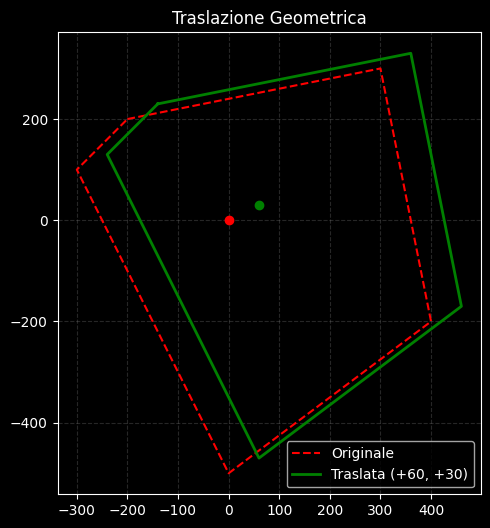

In [42]:
fig2, ax2 = plt.subplots(figsize=(6, 6))
ax2.set_aspect('equal')
ax2.grid(True, linestyle='--', alpha=0.3, color='gray')
ax2.set_title("Traslazione Geometrica")

# Definiamo il vettore di spostamento (offset)
offset_x = 60
offset_y = 30

# Eseguiamo la traslazione ed estraiamo le nuove coordinate.
# Il "method chaining": translate() restituisce 'self' già aggiornato,
# permettendoci di accedere direttamente all'oggetto.shapely sulla stessa riga.
x_traslato, y_traslato = copia_per_traslazione.translate(offset_x, offset_y).shapely.exterior.coords.xy

# Plottiamo la forma originale e la sua origine iniziale (in rosso)
ax2.plot(*forma_generica.shapely.exterior.xy, color='red', linestyle='--', label="Originale")
ax2.plot(forma_generica.origin[0], forma_generica.origin[1], color='red', linestyle='', marker='o', linewidth=2)

# Plottiamo la forma traslata e la sua NUOVA origine (in verde)
# La rappresentazione visiva dimostra che il punto di ancoraggio ha seguito coerentemente la figura
ax2.plot(x_traslato, y_traslato, color='green', linestyle='-', linewidth=2, label=f"Traslata (+{offset_x}, +{offset_y})")
ax2.plot(copia_per_traslazione.origin[0], copia_per_traslazione.origin[1], color='green', linestyle='', marker='o', linewidth=2)

ax2.legend()
plt.show()

### 2. Rotazione

La rotazione applica un movimento circolare alla figura (in senso antiorario, con angolo espresso in gradi).

La particolarità del metodo `rotate` della classe `Shape` è la possibilità di scegliere il **punto di cerniera** della rotazione tramite il parametro `ref`:
* **Rotazione attorno all'Origine (`ref="origin"`):** La figura ruota usando il suo punto di ancoraggio come perno. L'origine rimane fissa, mentre l'intera forma traccia un arco nello spazio.
* **Rotazione attorno al Baricentro (`ref="barycenter"`):** La figura ruota "su se stessa" come una trottola. In questo caso, il metodo calcola matematicamente lo spostamento dell'Origine, facendola orbitare attorno al baricentro affinché il sistema di riferimento locale rimanga perfettamente coerente con i vertici della figura.

Nel grafico seguente testeremo la rotazione baricentrica.

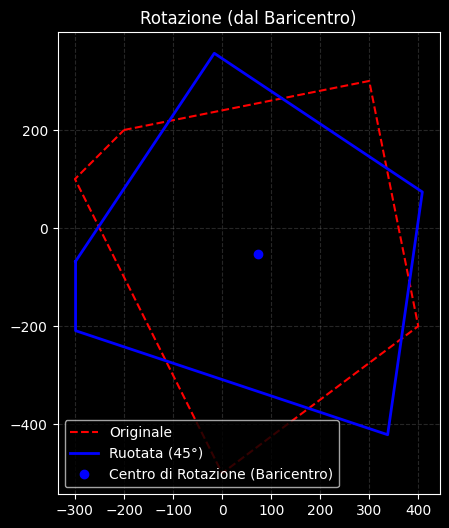

In [43]:
fig3, ax3 = plt.subplots(figsize=(6, 6))
ax3.set_aspect('equal')
ax3.grid(True, linestyle='--', alpha=0.3, color='gray')
ax3.set_title("Rotazione (dal Baricentro)")

angolo_in_gradi = 45

# Estrazione coordinate dopo la trasformazione
# Anche qui sfruttiamo il method chaining per ruotare ed estrarre le coordinate in un colpo solo.
# Passiamo esplicitamente ref="barycenter" per ruotare la forma sul proprio asse.
x_rot, y_rot = copia_per_rotazione.rotate(angle=angolo_in_gradi, ref="barycenter").shapely.exterior.coords.xy

# Plottiamo la forma originale (Rossa)
ax3.plot(*forma_generica.shapely.exterior.xy, color='red', linestyle='--', label="Originale")

# Plottiamo la forma ruotata (Blu) e il suo punto di perno
ax3.plot(x_rot, y_rot, color='blue', linestyle='-', linewidth=2, label=f"Ruotata ({angolo_in_gradi}°)")
ax3.plot(*copia_per_rotazione.barycenter, color='blue', marker='o', linestyle='', label="Centro di Rotazione (Baricentro)")

ax3.legend()
plt.show()

### 3. Analisi Critica: Scala vs Buffer (Offset)

Questo è il test visivo più importante per chi lavora con forme irregolari (es. CAD, architettura, o percorsi CNC).
Se vogliamo creare una "geometria interna" rimpicciolita, qual è il metodo matematicamente corretto? Dipende dal nostro obiettivo ingegneristico:

* **Ridimensionamento Baricentrica (Linea Verde):** È una trasformazione affine pura. Moltiplica la distanza di ogni vertice dal baricentro per un fattore (in questo caso **0.6**, ovvero il 60%).
  * *Difetto nei contorni:* **Deforma gli spessori.** I vertici più distanti dal centro subiscono uno spostamento assoluto maggiore rispetto a quelli vicini, creando "pareti" interne di larghezza disomogenea.
* **Buffer / Offset Interno (Linea Arancione):** È un'operazione morfologica. Sottrae una distanza costante (es. **-10.0 mm**) perpendicolarmente a ogni segmento del perimetro.
  * *Vantaggio nei contorni:* Mantiene uno **spessore del muro perfettamente costante** in ogni punto della figura geometrica, rispettando la topologia originale.

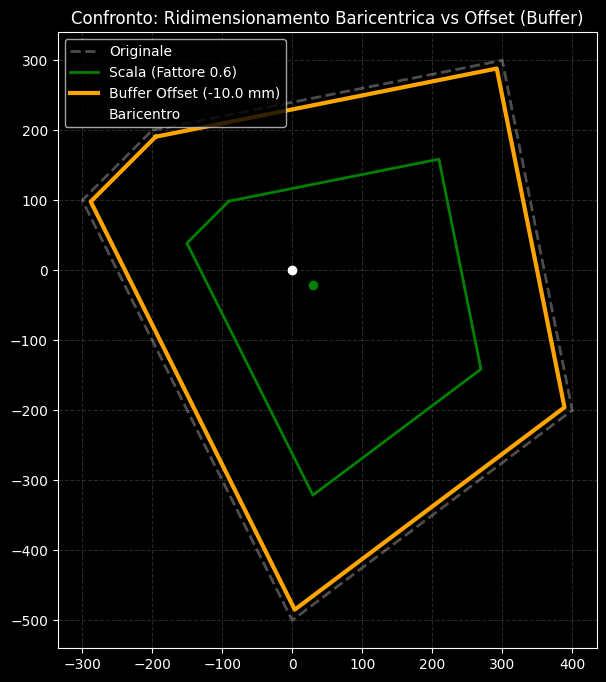

In [44]:
fig4, ax4 = plt.subplots(figsize=(8, 8))
ax4.set_aspect('equal')
ax4.grid(True, linestyle='--', alpha=0.3, color='gray')
ax4.set_title("Confronto: Ridimensionamento Baricentrica vs Offset (Buffer)")

# 1. Perimetro Originale (Riferimento visivo)
ax4.plot(forma_generica.origin[0], forma_generica.origin[1], color='white', linestyle='', marker='o', linewidth=2)
ax4.plot(*forma_generica.shapely.exterior.xy, color='white', alpha=0.3, linestyle='--', linewidth=2, label="Originale")

# 2. Ridimensionamento (Trasformazione Affine)
fattore_di_scala = 0.6
# Rimpiccioliamo del 40% rispetto al baricentro
x_scale, y_scale = copia_per_scala.scale(fattore_di_scala, fattore_di_scala, ref="barycenter").shapely.exterior.coords.xy
ax4.plot(x_scale, y_scale, color='green', linestyle='-', linewidth=2, label=f"Scala (Fattore {fattore_di_scala})")
ax4.plot(copia_per_scala.origin[0], copia_per_scala.origin[1], color='green', linestyle='', marker='o', linewidth=2)

# 3. Buffer Interno (Operazione Morfologica tramite Shapely)
offset_negativo = -10.0
# Utilizziamo l'oggetto originario.
# Nota: join_style=2 (mitre) gestisce la creazione di spigoli vivi (non arrotondati) agli angoli.
x_buffer, y_buffer = forma_generica.shapely.buffer(offset_negativo, join_style=2).exterior.coords.xy
ax4.plot(x_buffer, y_buffer, color='orange', linestyle='-', linewidth=3, label=f"Buffer Offset ({offset_negativo} mm)")

# Evidenziamo il baricentro: è il 'cuore' da cui i punti verdi si sono allontanati o avvicinati
ax4.plot(*forma_generica.barycenter, color='black', marker='+', markersize=10, linestyle='', label="Baricentro")

ax4.legend()
plt.show()

## 📏 Discretizzazione del Perimetro

Molte applicazioni fisiche (come la robotica, la stampa 3D o la generazione di percorsi G-Code per CNC) non possono gestire geometrie continue. Richiedono un elenco finito e discreto di coordinate spaziali.
La **discretizzazione** risolve questo problema percorrendo il perimetro e campionando un punto ogni intervallo regolare (`discretization_step`).

La classe `Shape` include un motore di validazione molto avanzato per calcolare questo passo:
* **Limiti Dinamici (`min` e `max`):** Evitano di generare milioni di punti (sovraccarico di memoria) o troppo pochi (perdita della forma).
* **Passi Sicuri (`sure_steps`):** La classe calcola automaticamente i divisori ottimali basati sul Massimo Comune Divisore (MCD) della lunghezza dei segmenti. Usare un passo "sicuro" garantisce che il campionamento non salti gli spigoli originali della figura.
* **Auto-Correzione (Casting):** Se si tenta di impostare un passo arbitrario (es. `4.5`), il *setter* della classe interviene e lo adatta automaticamente al "passo sicuro" matematicamente più vicino, prevenendo la deformazione del profilo.

In [45]:
# Analisi dei parametri di discretizzazione (Calcolati on-demand tramite lazy caching)
print(f"Step minimo consentito: {forma_generica.min_discretization_step}")
print(f"Step massimo (MCD dei segmenti): {forma_generica.max_discretization_step}")
print(f"Lista dei passi sicuri calcolati: {forma_generica.sure_steps}")

# Proviamo a forzare un passo arbitrario.
# Il setter della proprietà intercetta questo valore.
# Se 4.5 non è un "sure step", lo arrotonderà al passo sicuro più vicino per evitare deformazioni!
forma_generica.discretization_step = 150

print(f"Step effettivamente impostato dalla classe: {forma_generica.discretization_step}")

Step minimo consentito: 1
Step massimo (MCD dei segmenti): 141.4214
Lista dei passi sicuri calcolati: [0.0000e+00 1.0000e-02 2.0000e-02 3.0000e-02 4.0000e-02 5.0000e-02
 6.0000e-02 7.0000e-02 8.0000e-02 9.0000e-02 1.0000e-01 1.1000e-01
 1.2000e-01 1.3000e-01 1.4000e-01 1.5000e-01 1.6000e-01 1.7000e-01
 1.8000e-01 1.9000e-01 2.0000e-01 2.1000e-01 2.2000e-01 2.3000e-01
 2.4000e-01 2.5000e-01 2.6000e-01 2.7000e-01 2.8000e-01 2.9000e-01
 3.0000e-01 3.1000e-01 3.2000e-01 3.3000e-01 3.4000e-01 3.5000e-01
 3.6000e-01 3.8000e-01 3.9000e-01 4.0000e-01 4.1000e-01 4.2000e-01
 4.3000e-01 4.4000e-01 4.5000e-01 4.6000e-01 4.7000e-01 4.8000e-01
 4.9000e-01 5.0000e-01 5.1000e-01 5.2000e-01 5.3000e-01 5.4000e-01
 5.5000e-01 5.6000e-01 5.7000e-01 5.8000e-01 5.9000e-01 6.0000e-01
 6.1000e-01 6.2000e-01 6.4000e-01 6.5000e-01 6.7000e-01 6.8000e-01
 6.9000e-01 7.0000e-01 7.1000e-01 7.2000e-01 7.3000e-01 7.4000e-01
 7.7000e-01 7.9000e-01 8.0000e-01 8.1000e-01 8.2000e-01 8.3000e-01
 8.4000e-01 8.6000e-01 8.70

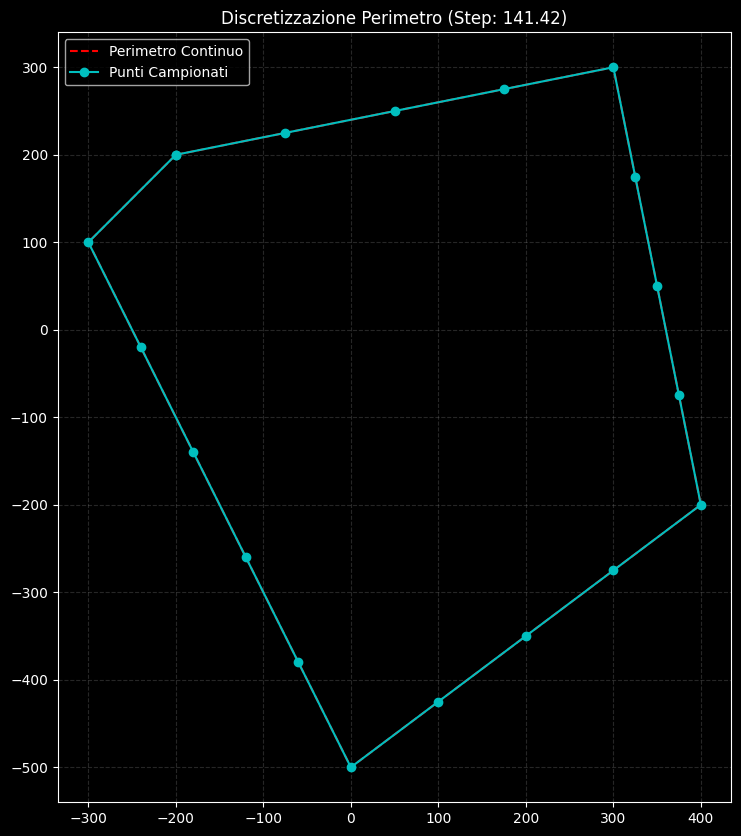

In [46]:
# Generiamo l'array numpy con le coordinate dei punti discretizzati lungo il perimetro
chiusura = forma_generica.discretize()

# Per chiudere visivamente il loop nel grafico, aggiungiamo il primo punto alla fine dell'array
chiusura = np.vstack((chiusura, chiusura[0]))

# Estraiamo le colonne X e Y per Matplotlib
x, y = chiusura[:, 0], chiusura[:, 1]

# Impostiamo il grafico
fig5, ax5 = plt.subplots(figsize=(10, 10)) # Ridotto da 20x20 per comodità di lettura a schermo
ax5.set_aspect('equal')
ax5.grid(True, linestyle='--', alpha=0.3, color='gray')
ax5.set_title(f"Discretizzazione Perimetro (Step: {forma_generica.discretization_step:.2f})")

# Plottiamo la sagoma continua in background (Rossa tratteggiata)
ax5.plot(*forma_generica.shapely.exterior.xy, color='red', linestyle='--', label="Perimetro Continuo")

# Plottiamo i punti campionati (Ciano)
ax5.plot(x, y, linestyle='-', color='c', marker='o', markersize=6, label="Punti Campionati")

ax5.legend()
plt.show()

In [47]:
# 1. Separiamo i punti di partenza e di arrivo per ogni segmento
# (Escludiamo l'ultimo punto da "correnti" e il primo da "successivi")
punti_correnti = chiusura[:-1]
punti_successivi = chiusura[1:]

# 2. Calcolo vettoriale delle distanze euclidee reali
distanze_reali = np.linalg.norm(punti_successivi - punti_correnti, axis=1)

# 3. Calcolo degli errori
step_teorico = forma_generica.discretization_step
errore_assoluto = np.abs(step_teorico - distanze_reali)
errore_relativo_perc = (errore_assoluto / step_teorico) * 100

# 4. Stampa formattata dei risultati
print(f"--- ANALISI ERRORE (Step Teorico: {step_teorico:.4f} mm) ---\n")

for i in range(len(distanze_reali)):
    dist = distanze_reali[i]
    err_abs = errore_assoluto[i]
    err_perc = errore_relativo_perc[i]

    # Isiliamo visivamente l'ultimo segmento (chiusura)
    if i == len(distanze_reali) - 1:
        print("-" * 65)
        print(f"Chiusura | Distanza: {dist:.4f} | Err Assoluto: {err_abs:.4f} | Err Rel: {err_perc:.2f}% (Fisiologico)")
    else:
        print(f"Step {i+1:02d}   | Distanza: {dist:.4f} | Err Assoluto: {err_abs:.4f} | Err Rel: {err_perc:.2f}%")

--- ANALISI ERRORE (Step Teorico: 141.4214 mm) ---

Step 01   | Distanza: 127.4755 | Err Assoluto: 13.9459 | Err Rel: 9.86%
Step 02   | Distanza: 127.4755 | Err Assoluto: 13.9459 | Err Rel: 9.86%
Step 03   | Distanza: 127.4755 | Err Assoluto: 13.9459 | Err Rel: 9.86%
Step 04   | Distanza: 127.4755 | Err Assoluto: 13.9459 | Err Rel: 9.86%
Step 05   | Distanza: 127.4755 | Err Assoluto: 13.9459 | Err Rel: 9.86%
Step 06   | Distanza: 127.4755 | Err Assoluto: 13.9459 | Err Rel: 9.86%
Step 07   | Distanza: 127.4755 | Err Assoluto: 13.9459 | Err Rel: 9.86%
Step 08   | Distanza: 127.4755 | Err Assoluto: 13.9459 | Err Rel: 9.86%
Step 09   | Distanza: 125.0000 | Err Assoluto: 16.4214 | Err Rel: 11.61%
Step 10   | Distanza: 125.0000 | Err Assoluto: 16.4214 | Err Rel: 11.61%
Step 11   | Distanza: 125.0000 | Err Assoluto: 16.4214 | Err Rel: 11.61%
Step 12   | Distanza: 125.0000 | Err Assoluto: 16.4214 | Err Rel: 11.61%
Step 13   | Distanza: 134.1641 | Err Assoluto: 7.2573 | Err Rel: 5.13%
Step 14  

## 🕸️ Generazione di un Infill a Griglia (Riempimento / Hatching)

In molte applicazioni manifatturiere (come lo slicing per la stampa 3D o la generazione di percorsi utensile per lo svuotamento CNC), non basta operare sul perimetro esterno: è necessario generare una struttura interna di riempimento, nota come **Infill**.

Il codice seguente illustra come sovrapporre un pattern a griglia (ortogonale) alla nostra geometria, calcolando matematicamente i segmenti validi che cadono all'interno del poligono.

### Dettagli Tecnici dell'Implementazione

L'algoritmo si basa su tre passaggi fondamentali:
1. **Estrazione del Bounding Box (`bounds`):** Sfruttiamo i limiti geometrici assoluti della figura (min/max X e Y) per definire l'area di lavoro ed evitare di tracciare linee guida inutilmente lunghe.
2. **Operazioni Booleane (`intersection`):** Vengono generate delle linee rette passanti per l'intera area di lavoro (tratteggiate in grigio). Sfruttando la funzione di intersezione di Shapely, la retta viene letteralmente "ritagliata" usando la maschera della nostra figura, conservando solo la porzione interna.
3. **Resilienza alle Concavità (`MultiLineString` vs `LineString`):** Questo è l'aspetto più robusto del codice. Se la forma è irregolare o concava (es. a forma di "C" o "U"), una singola linea retta potrebbe entrare, uscire nel vuoto, e rientrare nella figura. In questi casi, Shapely non restituisce un singolo segmento, ma una geometria multipla (`MultiLineString`). L'algoritmo intercetta il `geom_type` ed estrae dinamicamente tutti i sotto-segmenti isolati, prevenendo errori di rendering.

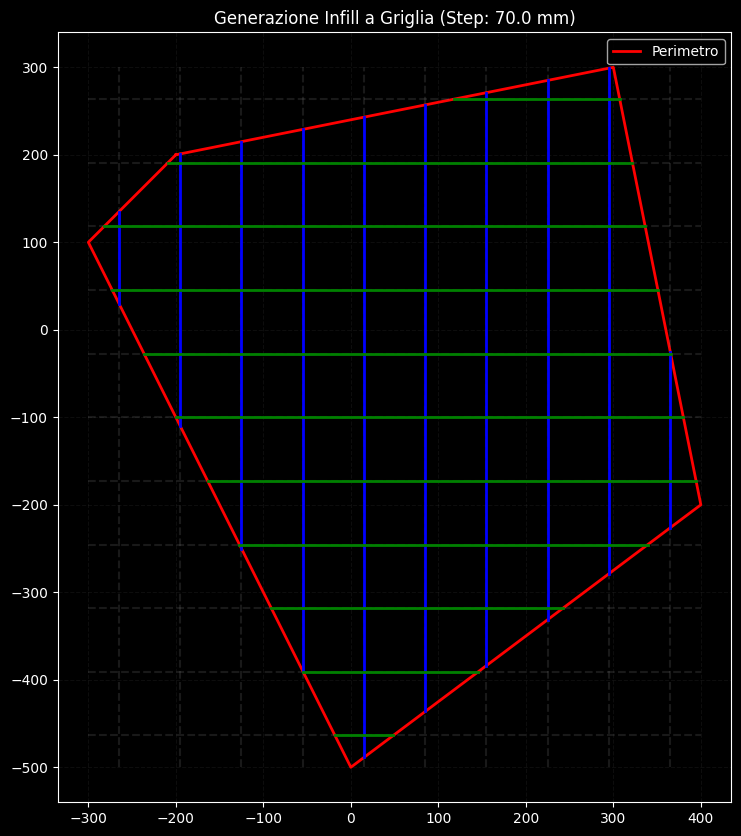

In [48]:
# 1. Estrazione dei limiti (Bounding Box)
x_0, y_0, x_f, y_f = forma_generica.bounds

# 2. Impostazione parametri griglia
grid_step = 70.0
# offset_padding = 20.0 # (Opzionale, non lo stavi usando ma puoi usarlo per restringere la griglia)

# Calcolo del numero di linee necessarie
n_x = int(np.round((x_f - x_0) / grid_step))
n_y = int(np.round((y_f - y_0) / grid_step))

linee_interne_verticali = []
linee_interne_orizzontali = []

# 3. Setup Grafico
fig6, ax6 = plt.subplots(figsize=(10, 10))
ax6.set_aspect('equal')
ax6.grid(True, linestyle='--', alpha=0.1, color='gray')
ax6.set_title(f"Generazione Infill a Griglia (Step: {grid_step} mm)")

poly = forma_generica.shapely

# PLOT FONDAMENTALE: Disegniamo il perimetro rosso per dare contesto visivo
ax6.plot(*poly.exterior.xy, color='red', linewidth=2, label="Perimetro")

# 4. Generazione Linee Verticali
passo_x = (x_f - x_0) / n_x if n_x > 0 else grid_step
for i in range(n_x):
    x_curr = passo_x / 2 + x_0 + i * passo_x
    linea_vert = LineString([(x_curr, y_0), (x_curr, y_f)])

    # Disegniamo la linea di costruzione "infinita" in grigio chiaro
    ax6.plot(*linea_vert.xy, '--', color='grey', alpha=0.2)

    # Intersezione (Sintassi corretta: un solo argomento)
    intersezione = poly.intersection(linea_vert)

    if not intersezione.is_empty:
        # GESTIONE SICURA: Separiamo i casi in cui la linea viene spezzata (forme concave)
        if intersezione.geom_type == 'MultiLineString':
            for segmento in intersezione.geoms:
                linee_interne_verticali.append(segmento)
                ax6.plot(*segmento.xy, '-b', linewidth=2) # Linee blu interne
        elif intersezione.geom_type == 'LineString':
            linee_interne_verticali.append(intersezione)
            ax6.plot(*intersezione.xy, '-b', linewidth=2)

# 5. Generazione Linee Orizzontali (Completato)
passo_y = (y_f - y_0) / n_y if n_y > 0 else grid_step
for i in range(n_y):
    y_curr = passo_y / 2 + y_0 + i * passo_y
    linea_hor = LineString([(x_0, y_curr), (x_f, y_curr)])

    ax6.plot(*linea_hor.xy, '--', color='grey', alpha=0.2)

    intersezione = poly.intersection(linea_hor)

    if not intersezione.is_empty:
        if intersezione.geom_type == 'MultiLineString':
            for segmento in intersezione.geoms:
                linee_interne_orizzontali.append(segmento)
                ax6.plot(*segmento.xy, '-g', linewidth=2) # Linee verdi interne
        elif intersezione.geom_type == 'LineString':
            linee_interne_orizzontali.append(intersezione)
            ax6.plot(*intersezione.xy, '-g', linewidth=2)

ax6.legend()
plt.show()

In [49]:
print("--- LUNGHEZZA SEGMENTI ORIZZONTALI (BLU) ---")
distanze_orizzontali = []
for idx, linea in enumerate(linee_interne_orizzontali):
    distanza = linea.length
    distanze_orizzontali.append(distanza)
    print(f"Segmento {idx+1}: {distanza:.2f} mm")

--- LUNGHEZZA SEGMENTI ORIZZONTALI (BLU) ---
Segmento 1: 66.67 mm
Segmento 2: 200.00 mm
Segmento 3: 333.33 mm
Segmento 4: 466.67 mm
Segmento 5: 558.18 mm
Segmento 6: 580.00 mm
Segmento 7: 601.82 mm
Segmento 8: 623.64 mm
Segmento 9: 618.18 mm
Segmento 10: 530.91 mm
Segmento 11: 189.09 mm


In [50]:
print("\n--- LUNGHEZZA SEGMENTI VERTICALI (ROSSI) ---")
distanze_verticali = []
for idx, linea in enumerate(linee_interne_verticali):
    distanza = linea.length
    distanze_verticali.append(distanza)
    print(f"Segmento {idx+1}: {distanza:.2f} mm")



--- LUNGHEZZA SEGMENTI VERTICALI (ROSSI) ---
Segmento 1: 105.00 mm
Segmento 2: 311.00 mm
Segmento 3: 465.00 mm
Segmento 4: 619.00 mm
Segmento 5: 731.75 mm
Segmento 6: 693.25 mm
Segmento 7: 654.75 mm
Segmento 8: 616.25 mm
Segmento 9: 577.75 mm
Segmento 10: 201.25 mm


In [51]:
distanze_orizzontali_np = np.asarray(distanze_orizzontali, dtype=np.float64)
distanze_verticali_np = np.asarray(distanze_verticali, dtype=np.float64)

print(f"\nMedia lunghezza orizzontale: {np.mean(distanze_orizzontali_np):.2f}")
print(f"Media lunghezza verticale: {np.mean(distanze_verticali_np):.2f}")


Media lunghezza orizzontale: 433.50
Media lunghezza verticale: 497.50


In [52]:
mcd_orizzontale, _ = _tolerated_mcd(distanze_orizzontali_np, 10 ** (np.log10(np.min(distanze_orizzontali_np)) - 1))
mcd_verticale, _ = _tolerated_mcd(distanze_verticali_np, 10 ** (np.log10(np.min(distanze_verticali_np)) - 1))

print(f"MCD orizzontale: {mcd_orizzontale:.2f}")
print(f"MCD verticale: {mcd_verticale:.2f}")

MCD orizzontale: 13.00
MCD verticale: 26.00


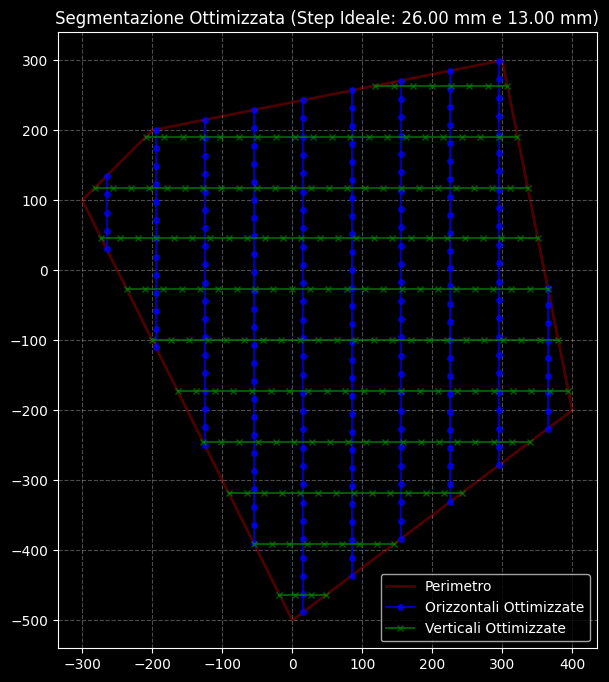

In [53]:
fig8, ax8 = plt.subplots(figsize=(8, 8))
ax8.set_aspect('equal')
ax8.grid(True, linestyle='--', alpha=0.3)

ax8.plot(*forma_generica.shapely.exterior.xy, color='red', alpha=0.3, linewidth=2, label="Perimetro")

step_ideale_verticale = mcd_verticale
step_ideale_orizzontale = mcd_orizzontale
ax8.set_title(f"Segmentazione Ottimizzata (Step Ideale: {step_ideale_verticale:.2f} mm e {step_ideale_orizzontale:.2f} mm)")
for idx, linea_da_segmentare in enumerate(linee_interne_verticali):
    lunghezza_linea = linea_da_segmentare.length

    n_segmenti = int(np.round(lunghezza_linea / step_ideale_verticale))

    if n_segmenti == 0:
        n_segmenti = 1

    distanze_ottimizzate = np.linspace(0, lunghezza_linea, n_segmenti + 1)
    punti_taglio = [linea_da_segmentare.interpolate(d) for d in distanze_ottimizzate]
    x_coord = [p.x for p in punti_taglio]
    y_coord = [p.y for p in punti_taglio]

    label = "Orizzontali Ottimizzate" if idx == 0 else ""
    ax8.plot(x_coord, y_coord, 'o-', color='blue', markersize=4, linewidth=1.5, alpha=0.7, label=label)

for idx, linea_da_segmentare in enumerate(linee_interne_orizzontali):
    lunghezza_linea = linea_da_segmentare.length

    n_segmenti = int(np.round(lunghezza_linea / step_ideale_verticale))

    if n_segmenti == 0:
        n_segmenti = 1

    distanze_ottimizzate = np.linspace(0, lunghezza_linea, n_segmenti + 1)
    punti_taglio = [linea_da_segmentare.interpolate(d) for d in distanze_ottimizzate]
    x_coord = [p.x for p in punti_taglio]
    y_coord = [p.y for p in punti_taglio]

    label = "Verticali Ottimizzate" if idx == 0 else ""
    ax8.plot(x_coord, y_coord, 'x-', color='green', markersize=4, linewidth=1.5, alpha=0.7, label=label)

ax8.legend()
plt.show()

## 🎯 Infill Concentrico (Offset Iterativo e Biforcazione Topologica)

Un'alternativa fondamentale all'infill a griglia è il **riempimento concentrico** (noto anche come *Contour*, *Wall* o *Pocket Milling*). Questo approccio è onnipresente nello svuotamento tasche per le frese CNC o nella generazione dei perimetri esterni (shell) nella stampa 3D, poiché segue fedelmente il profilo dell'oggetto garantendo una finitura superficiale omogenea.

Il codice seguente genera questi percorsi annidati, affrontando e risolvendo una delle sfide topologiche più complesse della geometria computazionale.

### Dettagli Tecnici dell'Implementazione

L'algoritmo non si limita a disegnare linee più piccole, ma esegue una vera e propria simulazione morfologica:
1. **Buffer Iterativo (True Offset):** Sfruttiamo la funzione `buffer` di Shapely con valore negativo (`-offset_assoluto`) all'interno di un ciclo continuo. Ad ogni iterazione, la forma precedente viene "erosa" e usata come base per il calcolo successivo.
2. **Resilienza alla Biforcazione (`MultiPolygon`):** Man mano che un poligono irregolare si restringe, le sue pareti interne possono collidere. Quando ciò accade, il nucleo si divide, trasformando il `Polygon` singolo in un arcipelago di "isole" separate (`MultiPolygon`). Il codice intercetta dinamicamente questo cambio di stato topologico ed estrae i contorni di ciascuna isola per continuare l'erosione in modo indipendente.
3. **Condizione di Arresto Naturale (`is_empty`):** Il ciclo `while True` non usa contatori rigidi, ma termina elegantemente nell'esatto momento in cui l'offset negativo consuma l'ultimo millimetro quadrato di area disponibile, rendendo la geometria vuota. A corredo, viene stampato l'andamento dell'area residua ad ogni ciclo.

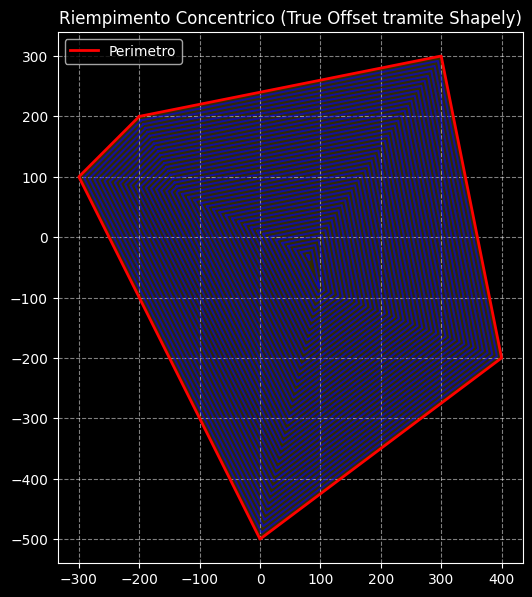

In [54]:
fig7, ax7 = plt.subplots(figsize=(6, 8))
ax7.set_aspect('equal')
ax7.grid(True, linestyle='--', alpha=0.5)
ax7.set_title("Riempimento Concentrico (True Offset tramite Shapely)")

x_ext, y_ext =forma_generica.shapely.exterior.xy
ax7.plot(x_ext, y_ext, '-r', linewidth=2, label="Perimetro")
ax7.fill(x_ext, y_ext, color='gold', alpha=0.2)

offset_assoluto = 7
ciclo = 0

poly_succession = []
current_poly = forma_generica.shapely
while True:
    current_poly = current_poly.buffer(-offset_assoluto, join_style=2)
    if current_poly.is_empty:
        break

    ciclo += 1
    if current_poly.geom_type == 'Polygon':
        polygons = [current_poly]
    elif current_poly.geom_type == 'MultiPolygon':
        polygons = current_poly.geoms
    else:
        break

    for poly in polygons:
        x_int, y_int = poly.exterior.xy
        ax7.plot(x_int, y_int, '-b', alpha=0.6)

    print(f"Ciclo {ciclo:02d} | Area rimanente: {current_poly.area:.2f}")

ax7.legend()
plt.show()